<a href="https://colab.research.google.com/github/Zuha55/Traffic-Accident-Severity-Prediction/blob/main/Accident_Prediction_(supervised).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Summary: Traffic Accident Severity Prediction

### Objective
Developed a supervised machine learning solution to predict traffic accident severity using real-world US accident data (2019-2023). The project addresses a multi-class classification problem with a strong focus on handling class imbalance.

### Key Contributions & Technical Skills Demonstrated

1.  **Data Acquisition & Preprocessing**: Managed a large-scale dataset (~5 million records), loading and filtering for relevant timeframes and features. Implemented robust missing value imputation (median for numeric, mode/FFill/BFill for categorical/temporal) and optimized data types for memory efficiency.

2.  **Exploratory Data Analysis (EDA)**: Performed comprehensive analysis to understand data distributions, identify class imbalance issues (e.g., Severity 2 dominating ~83% of records), and visualize key insights like top accident-prone states and feature correlations.

3. **Feature Engineering**: Created impactful features from raw data, including temporal aspects (hour, day, month, weekday, rush hour, weekend flags), geographical indicators (street type, state), and environmental conditions (grouped weather, daytime indicator). This enhanced model understanding of complex patterns.

4.  **Feature Selection**: Applied ANOVA F-test to identify and select the top 15 most statistically significant features influencing accident severity, reducing dimensionality and improving model focus.

5.  **Class Imbalance Handling**: Addressed severe class imbalance through stratified downsampling of the training data (balancing classes to 50,000 samples each) and computing balanced class weights for model training. This ensures models learn effectively from minority classes.

6.  **Model Development & Evaluation**: Implemented and trained a suite of supervised machine learning models, including Logistic Regression, Random Forest, Gradient Boosting, and XGBoost. Critically evaluated performance using appropriate metrics for imbalanced multi-class problems: **Weighted F1-score** (primary), **Weighted ROC-AUC**, Accuracy, and Macro F1-score. Utilized confusion matrices and ROC curves for in-depth performance analysis.

7.  **Key Findings**: Demonstrated that **Gradient Boosting** achieved the best overall performance with a Weighted F1-score of ~0.62 and strong discriminative power (Weighted ROC-AUC of ~0.83), highlighting its effectiveness in handling the complexity and imbalance of the dataset.

### Technologies Used
*   **Programming Languages**: Python
*   **Libraries**: Pandas, NumPy, Scikit-learn (StandardScaler, LabelEncoder, train_test_split, f_classif, classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve), XGBoost, Imbalanced-learn (SMOTE - *though downsampling was used for final models*), Matplotlib, Seaborn.

## Environment Setup and Libraries
This notebook was developed and executed using Google Colab due to dataset size and computational requirements. All experiments are reproducible using standard Python machine learning libraries.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/Accident dataset/archive.zip'
extract_path = '/content/accident_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


## Dataset Description
The dataset consists of structured US traffic accident records from 2016 to 2023 containing information related to road conditions, environmental factors, temporal attributes, and accident characteristics. The target variable is **accident severity**, which represents the impact level of each accident. Due to the real-world nature of the data, the dataset exhibits class imbalance, making it necessary to use appropriate evaluation metrics and resampling techniques.


In [ ]:
import os
os.listdir('/content/accident_data')


['US_Accidents_March23.csv']

## Data Loading
In this section, the dataset is loaded and relevant columns required for analysis are selected. Only necessary features are retained to optimize memory usage and computational efficiency.


In [ ]:
import pandas as pd

data_path = "/content/accident_data/US_Accidents_March23.csv"

selected_cols = [
    "Severity",
    "Start_Time",
    "State",
    "Distance(mi)",
    "Temperature(F)",
    "Visibility(mi)",
    "Precipitation(in)",
    "Wind_Speed(mph)",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Street",
    "Amenity", "Bump", "Crossing", "Junction", "Roundabout", "Stop", "Traffic_Signal"
]

dtypes = {
    "Severity": "int8",
    "Distance(mi)": "float32",
    "Temperature(F)": "float32",
    "Visibility(mi)": "float32",
    "Precipitation(in)": "float32",
    "Wind_Speed(mph)": "float32",
    "State": "category",
    "Weather_Condition": "object",
    "Sunrise_Sunset": "category",
    "Street": "object",
    "Amenity": "bool",
    "Bump": "bool",
    "Crossing": "bool",
    "Junction": "bool",
    "Roundabout": "bool",
    "Stop": "bool",
    "Traffic_Signal": "bool"
}

# Load dataset
df = pd.read_csv(
    data_path,
    usecols=selected_cols,
    dtype=dtypes
)

# Explicitly convert Start_Time to datetime
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

# Drop rows where Start_Time could not be parsed
df = df.dropna(subset=["Start_Time"])

# Filter last 5 years (2019-2023)
df = df[(df["Start_Time"].dt.year >= 2019) & (df["Start_Time"].dt.year <= 2023)]

print(f"Loaded dataset shape (2019-2023): {df.shape}")
print(df.head())


Loaded dataset shape (2019-2023): (4963691, 18)
        Severity          Start_Time  Distance(mi)            Street State  \
512217         1 2022-09-08 05:49:30          0.00     Army Trail Rd    IL   
512218         1 2022-09-08 02:02:05          0.00   Pearblossom Hwy    CA   
512219         1 2022-09-08 05:14:12          0.00          N 2nd St    VA   
512220         1 2022-09-08 06:22:57          0.00  Atlantic Blvd NE    OH   
512221         2 2022-09-08 06:36:20          1.91            I-77 N    OH   

        Temperature(F)  Visibility(mi)  Wind_Speed(mph)  Precipitation(in)  \
512217            58.0            10.0              0.0                0.0   
512218            86.0            10.0              6.0                0.0   
512219            68.0            10.0              8.0                0.0   
512220            62.0             7.0              6.0                0.0   
512221            63.0             7.0              3.0                0.0   

       Weather

## Exploratory Data Analysis
A brief exploratory analysis is performed to understand the distribution of accident severity classes and identify potential imbalance issues. This step provides context for subsequent preprocessing and modeling decisions.


,Severity,Start_Time,Distance(mi),Street,State,Temperature(F),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Junction,Roundabout,Stop,Traffic_Signal,Sunrise_Sunset
512217,1,2022-09-08 05:49:30,0.00,Army Trail Rd,IL,58.0,10.0,0.0,0.0,Fair,False,False,False,False,False,False,True,Night
512218,1,2022-09-08 02:02:05,0.00,Pearblossom Hwy,CA,86.0,10.0,6.0,0.0,Fair,False,False,False,False,False,False,False,Night
512219,1,2022-09-08 05:14:12,0.00,N 2nd St,VA,68.0,10.0,8.0,0.0,Mostly Cloudy,False,False,True,False,False,False,True,Night
512220,1,2022-09-08 06:22:57,0.00,Atlantic Blvd NE,OH,62.0,7.0,6.0,0.0,Mostly Cloudy,False,False,False,False,False,False,False,Night
512221,2,2022-09-08 06:36:20,1.91,I-77 N,OH,63.0,7.0,3.0,0.0,Partly Cloudy,False,False,False,False,False,False,False,Night


<class 'pandas.core.frame.DataFrame'>
Index: 4963691 entries, 512217 to 7728393
Data columns (total 18 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Severity           int8          
 1   Start_Time         datetime64[ns]
 2   Distance(mi)       float32       
 3   Street             object        
 4   State              category      
 5   Temperature(F)     float32       
 6   Visibility(mi)     float32       
 7   Wind_Speed(mph)    float32       
 8   Precipitation(in)  float32       
 9   Weather_Condition  object        
 10  Amenity            bool          
 11  Bump               bool          
 12  Crossing           bool          
 13  Junction           bool          
 14  Roundabout         bool          
 15  Stop               bool          
 16  Traffic_Signal     bool          
 17  Sunrise_Sunset     category      
dtypes: bool(7), category(2), datetime64[ns](1), float32(5), int8(1), object(2)
memory usage: 293.5+ MB
Non

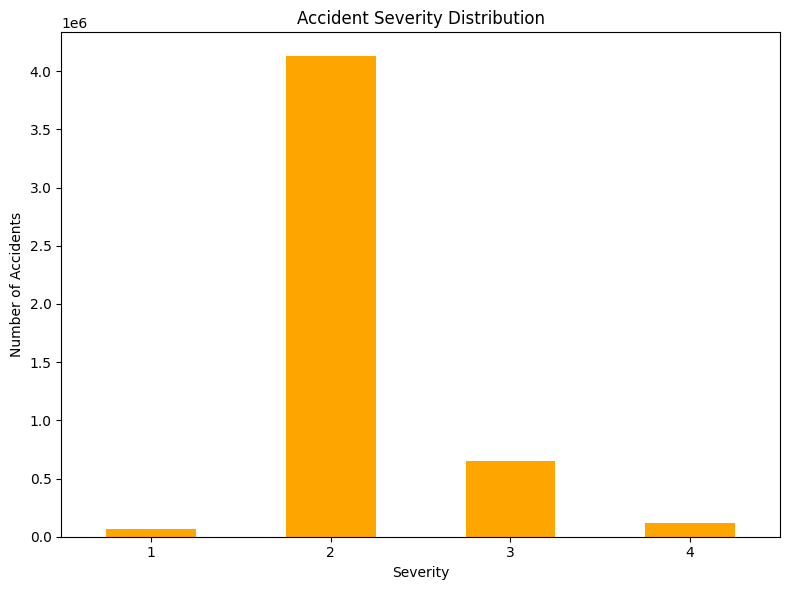


Severity Distribution (%):
Severity
1     1.341703
2    83.151127
3    13.079843
4     2.427327
Name: proportion, dtype: float64


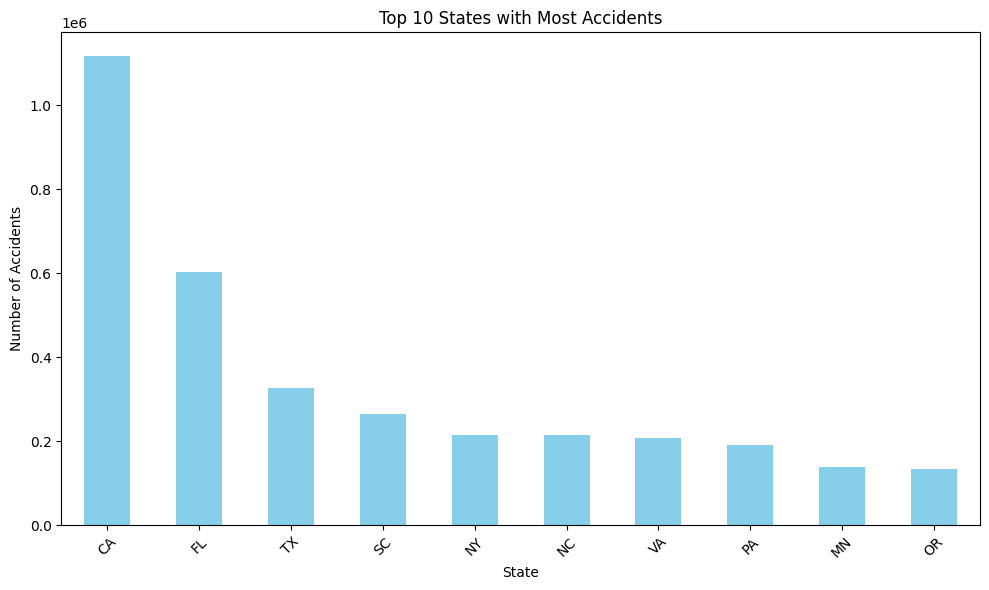


Top 10 States Table:
  State  Number_of_Accidents
0    CA              1117705
1    FL               602078
2    TX               325339
3    SC               263326
4    NY               215218
5    NC               213354
6    VA               207366
7    PA               190841
8    MN               138660
9    OR               133119

Numeric Features Summary:
       Distance(mi)  Temperature(F)  Visibility(mi)  Precipitation(in)  \
count  4.963691e+06    4.856444e+06    4.852769e+06       4.571013e+06   
mean   6.138281e-01    6.110689e+01    9.054785e+00       6.022832e-03   
std    1.811805e+00    1.904091e+01    2.668870e+00       5.452843e-02   
min    0.000000e+00   -8.900000e+01    0.000000e+00       0.000000e+00   
25%    0.000000e+00    4.800000e+01    1.000000e+01       0.000000e+00   
50%    5.900000e-02    6.300000e+01    1.000000e+01       0.000000e+00   
75%    5.340000e-01    7.600000e+01    1.000000e+01       0.000000e+00   
max    4.417500e+02    2.070000e+02    1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report

# Quick info
from IPython.display import display
display(df.head(5))

print(df.info())
print("\nShape of dataset:", df.shape)

# Severity distribution
print("\nSeverity Counts:")
print(df["Severity"].value_counts())

plt.figure(figsize=(8,6))
df["Severity"].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

severity_percent = df["Severity"].value_counts(normalize=True).sort_index() * 100
print("\nSeverity Distribution (%):")
print(severity_percent)

# Top 10 States
top_state = df['State'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_state.plot(kind='bar', color='skyblue')
plt.title('Top 10 States with Most Accidents')
plt.xlabel('State')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
top_state_table = top_state.reset_index()
top_state_table.columns = ['State', 'Number_of_Accidents']
print("\nTop 10 States Table:")
print(top_state_table)


# Numeric summary
numeric_cols = ["Distance(mi)", "Temperature(F)", "Visibility(mi)", "Precipitation(in)", "Wind_Speed(mph)"]
print("\nNumeric Features Summary:")
print(df[numeric_cols].describe())

# Missing values
print("\nMissing Values by Column:")
print(df.isna().sum())


In [ ]:
df.duplicated().sum()

np.int64(307574)

### Data Preprocessing and Feature Engineering Function

This section defines a comprehensive Python function, `preprocess_accident_data_labelencoded`, designed to clean, transform, and create new features from the raw accident data. This function encapsulates all steps from missing value imputation to temporal feature extraction, street type classification, weather grouping, and final scaling and label encoding, preparing the dataset for machine learning models.

### Details of Data Preprocessing and Feature Engineering

This section defines and applies a comprehensive preprocessing and feature engineering pipeline. The `preprocess_accident_data_labelencoded` function handles:

*   **Missing Values**: `Start_Time` is forward/backward filled, boolean flags are filled with 0, numeric features with their median, and categorical features with their mode.
*   **Temporal Features**: Extracts hour, day, month, weekday, and creates `Is_Weekend` and `Rush_Hour` flags from `Start_Time`.
*   **Street Type**: Derives a simplified `Street_Type` (e.g., 'Highway', 'Street', 'Boulevard') from the raw `Street` names.
*   **Light Condition**: Converts `Sunrise_Sunset` into a binary `Is_Daytime` feature.
*   **Weather Grouping**: Categorizes detailed `Weather_Condition` into broader groups like 'Rainy', 'Snowy', 'Clear', etc.
*   **Column Dropping**: Removes original `Street`, `Weather_Condition`, and `Sunrise_Sunset` columns after feature extraction.
*   **Scaling**: Applies `StandardScaler` to numeric features.
*   **Label Encoding**: Converts high-cardinality categorical features (`State`, `Street_Type`, `Weather_Group`) into numerical labels for model compatibility.

The function returns the processed DataFrame and the fitted scalers/encoders for consistency when processing new data.

In [ ]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

def preprocess_accident_data_labelencoded(df, scaler=None, fit_scaler=True):
    df = df.copy()

    # Handle missing values
    df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
    df['Start_Time'] = df['Start_Time'].ffill().bfill()

    bool_cols = ['Amenity','Bump','Crossing','Junction','Roundabout','Stop','Traffic_Signal']
    for col in bool_cols:
        df[col] = df[col].fillna(0).astype('int8')

    numeric_cols = ['Distance(mi)','Temperature(F)','Visibility(mi)','Wind_Speed(mph)','Precipitation(in)']
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median()).astype('float32')

    categorical_cols = ['Street','Weather_Condition','Sunrise_Sunset','State']
    for col in categorical_cols:
        df[col] = df[col].astype(str).fillna(df[col].mode()[0])

    # Temporal features
    df['Start_Hour'] = df['Start_Time'].dt.hour.astype('int8')
    df['Start_Day'] = df['Start_Time'].dt.day.astype('int8')
    df['Start_Month'] = df['Start_Time'].dt.month.astype('int8')
    df['Start_Weekday'] = df['Start_Time'].dt.weekday.astype('int8')
    df['Is_Weekend'] = df['Start_Weekday'].isin([5,6]).astype('int8')
    df['Rush_Hour'] = df['Start_Hour'].apply(lambda x: 1 if 7<=x<=9 or 16<=x<=18 else 0).astype('int8')

    # Street type
    def get_street_type(name):
        name = str(name).lower()
        if any(x in name for x in ['hwy','highway','i-','us-']): return 'Highway'
        elif 'st' in name or 'street' in name: return 'Street'
        elif 'blvd' in name or 'boulevard' in name: return 'Boulevard'
        elif 'ave' in name or 'avenue' in name: return 'Avenue'
        elif 'rd' in name or 'road' in name: return 'Road'
        elif 'ln' in name or 'lane' in name: return 'Lane'
        elif 'dr' in name or 'drive' in name: return 'Drive'
        elif 'cir' in name or 'circle' in name: return 'Circle'
        elif 'way' in name: return 'Way'
        elif 'pl' in name or 'place' in name: return 'Place'
        else: return 'Other'
    df['Street_Type'] = df['Street'].apply(get_street_type)

    # Light condition
    df['Is_Daytime'] = df['Sunrise_Sunset'].apply(lambda x: 1 if x=='Day' else 0)

    # Weather grouping
    def weather_group(condition):
        condition = str(condition)
        if any(x in condition for x in ['Rain','Drizzle','Showers']): return 'Rainy'
        elif any(x in condition for x in ['Snow','Sleet','Wintry Mix']): return 'Snowy'
        elif any(x in condition for x in ['Clear','Fair','Sunny']): return 'Clear'
        elif any(x in condition for x in ['Fog','Mist','Haze']): return 'Foggy'
        elif any(x in condition for x in ['Thunder','T-Storm','Lightning']): return 'Stormy'
        elif any(x in condition for x in ['Dust','Blowing Dust','Sand']): return 'Dusty'
        elif any(x in condition for x in ['Hail','Funnel','Tornado','Squalls']): return 'Severe'
        else: return 'Other'
    df['Weather_Group'] = df['Weather_Condition'].apply(weather_group)

    # Drop redundant columns
    df.drop(columns=['Street','Weather_Condition','Sunrise_Sunset'], inplace=True)

    # Scaling numeric features
    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    else:
        df[numeric_cols] = scaler.transform(df[numeric_cols])

    # Label encoding
    le_state = LabelEncoder()
    df['State'] = le_state.fit_transform(df['State'])
    le_street = LabelEncoder()
    df['Street_Type'] = le_street.fit_transform(df['Street_Type'])
    le_weather = LabelEncoder()
    df['Weather_Group'] = le_weather.fit_transform(df['Weather_Group'])

    return df, scaler, le_state, le_street, le_weather

# Apply preprocessing
df1, scaler, le_state, le_street, le_weather = preprocess_accident_data_labelencoded(df)
print("Processed dataset shape:", df1.shape)
df1.head()


Processed dataset shape: (4963691, 24)


,Severity,Start_Time,Distance(mi),State,Temperature(F),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,...,Traffic_Signal,Start_Hour,Start_Day,Start_Month,Start_Weekday,Is_Weekend,Rush_Hour,Street_Type,Is_Daytime,Weather_Group
512217,1,2022-09-08 05:49:30,-0.334276,12,-0.166592,0.356144,-1.352732,-0.105316,0,0,...,1,5,8,9,3,0,0,8,0,0
512218,1,2022-09-08 02:02:05,-0.334276,3,1.315258,0.356144,-0.243475,-0.105316,0,0,...,0,2,8,9,3,0,0,4,0,0
512219,1,2022-09-08 05:14:12,-0.334276,43,0.362640,0.356144,0.126277,-0.105316,0,0,...,1,5,8,9,3,0,0,9,0,3
512220,1,2022-09-08 06:22:57,-0.334276,33,0.045100,-0.800057,-0.243475,-0.105316,0,0,...,0,6,8,9,3,0,0,1,0,3
512221,2,2022-09-08 06:36:20,0.705864,33,0.098024,-0.800057,-0.798103,-0.105316,0,0,...,0,6,8,9,3,0,0,4,0,3


### Post-Preprocessing Data Information

After applying the preprocessing and feature engineering steps, this cell displays a summary of the DataFrame (`df1.info()`). This helps to verify data types, confirm the absence of missing values (after imputation), and understand the memory usage of the transformed dataset, ensuring it's ready for model training.

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4963691 entries, 512217 to 7728393
Data columns (total 24 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Severity           int8          
 1   Start_Time         datetime64[ns]
 2   Distance(mi)       float32       
 3   State              int64         
 4   Temperature(F)     float32       
 5   Visibility(mi)     float32       
 6   Wind_Speed(mph)    float32       
 7   Precipitation(in)  float32       
 8   Amenity            int8          
 9   Bump               int8          
 10  Crossing           int8          
 11  Junction           int8          
 12  Roundabout         int8          
 13  Stop               int8          
 14  Traffic_Signal     int8          
 15  Start_Hour         int8          
 16  Start_Day          int8          
 17  Start_Month        int8          
 18  Start_Weekday      int8          
 19  Is_Weekend         int8          
 20  Rush_Hour          int8 

### Applying ANOVA F-test for Feature Selection

This code block performs an ANOVA F-test to assess the statistical significance of each numerical feature's relationship with the target variable 'Severity'.

*   **`X_numeric`**: Selects only the numerical features from the preprocessed DataFrame.
*   **`f_classif(X_numeric, y)`**: Calculates F-scores and p-values, indicating the strength of the relationship between each feature and the target.
*   **`anova_scores`**: A DataFrame is created to store the F-scores and p-values, which are then sorted in descending order of F-score. Features with higher F-scores are considered more predictive of the target variable.

In [ ]:
X = df1.drop(columns=['Severity', 'Start_Time'])  # Drop target + datetime
y = df1['Severity']
X_numeric = X.select_dtypes(include=['int8','int32','int64','float32','float64'])

from sklearn.feature_selection import SelectKBest, f_classif
f_values, p_values = f_classif(X_numeric, y)

anova_scores = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F_Score': f_values,
    'p_Value': p_values
})

anova_scores.sort_values(by='F_Score', ascending=False, inplace=True)
print(anova_scores.head(20))


              Feature       F_Score       p_Value
12     Traffic_Signal  24191.607452  0.000000e+00
8            Crossing  20860.045881  0.000000e+00
0        Distance(mi)  13608.563187  0.000000e+00
2      Temperature(F)   9106.185703  0.000000e+00
20         Is_Daytime   6972.750805  0.000000e+00
15        Start_Month   6345.847234  0.000000e+00
21      Weather_Group   4829.680523  0.000000e+00
19        Street_Type   4587.210103  0.000000e+00
11               Stop   4337.393826  0.000000e+00
18          Rush_Hour   3502.258620  0.000000e+00
1               State   3168.564459  0.000000e+00
17         Is_Weekend   2716.960005  0.000000e+00
4     Wind_Speed(mph)   2556.488988  0.000000e+00
9            Junction   2266.550298  0.000000e+00
13         Start_Hour   1732.537041  0.000000e+00
6             Amenity   1466.007847  0.000000e+00
16      Start_Weekday   1453.330521  0.000000e+00
5   Precipitation(in)    751.177779  0.000000e+00
3      Visibility(mi)    564.062939  0.000000e+00


### Visualizing Top Features by ANOVA F-score

This cell generates a bar plot to visualize the top 20 features based on their ANOVA F-scores. This visualization helps in quickly identifying the most influential features for predicting accident severity, aiding in potential dimensionality reduction and model interpretability.

/tmp/ipython-input-1231676623.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F_Score', y='Feature', data=top20, palette='viridis')


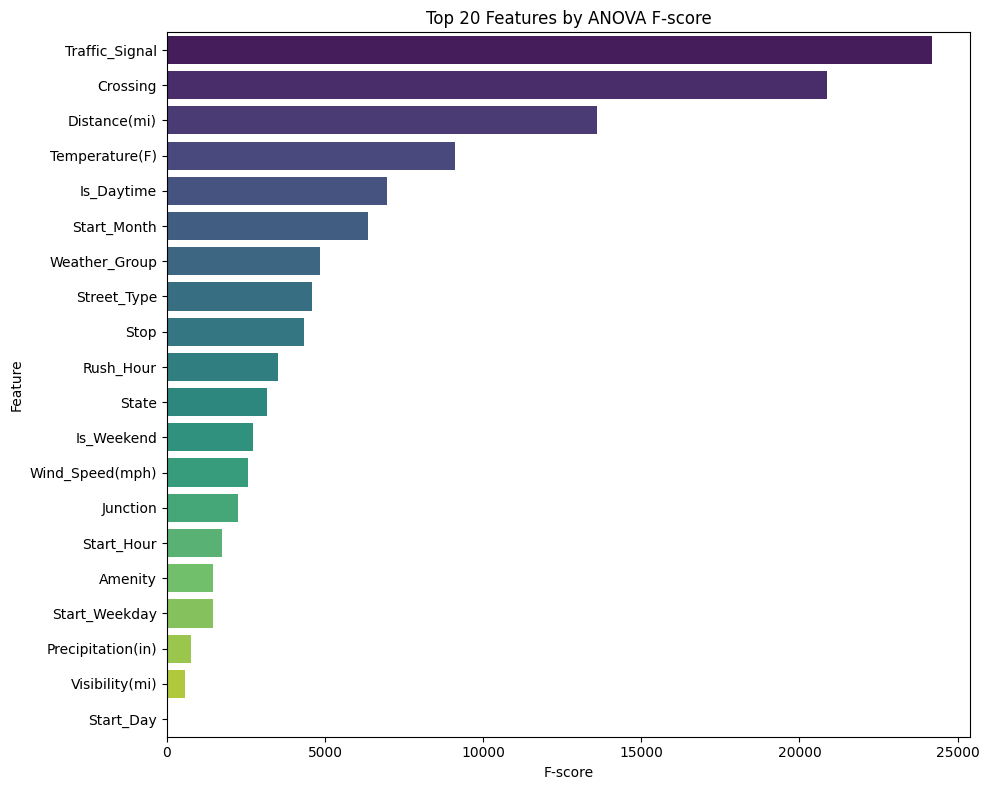

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Take top 20 features
top20 = anova_scores.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='F_Score', y='Feature', data=top20, palette='viridis')
plt.title('Top 20 Features by ANOVA F-score')
plt.xlabel('F-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Selecting Top Features for Modeling

Based on the ANOVA F-test, the top 15 features are selected from the `anova_scores` DataFrame. These selected features will be used as input for training the machine learning models. This step aims to reduce noise and improve computational efficiency by focusing on the most relevant predictors.

In [ ]:

top_features = anova_scores['Feature'].iloc[:15].tolist()  # top-15
X_top = X_numeric[top_features]  # numeric features only
y = df1['Severity']              # target


### Data Splitting into Training and Testing Sets

This cell divides the preprocessed data (`X`) and the target variable (`y`) into training and testing sets. A `test_size` of 0.2 (20%) is used, meaning 20% of the data will be held out for evaluating the models. `stratify=y` ensures that the proportion of each severity class is maintained in both the training and testing sets, which is crucial for imbalanced datasets. `random_state=42` ensures reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

X = df1.drop('Severity', axis=1)
y = df1['Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (3970952, 23)
Test size: (992739, 23)


### Preparing Feature Sets for Model Training

Here, the `Start_Time` column is explicitly dropped from both the training (`X_train`) and testing (`X_test`) feature sets to create `X_train_model` and `X_test_model`. This is done because `Start_Time` is a datetime object, which is not directly compatible with most machine learning algorithms, and its temporal features (hour, day, month, etc.) have already been extracted.

In [ ]:
X_train_model = X_train.drop(columns=['Start_Time'])
X_test_model = X_test.drop(columns=['Start_Time'])

### Downsampling the Training Data to Address Class Imbalance

To tackle the severe class imbalance, this cell performs stratified downsampling on the training data. For each `Severity` class, a maximum of `MAX_SAMPLES_PER_CLASS` (set to 50,000) samples are randomly selected. This creates a more balanced training dataset (`X_train_ds`, `y_train_ds`) where each severity level is equally represented, preventing models from being overly biased towards the majority class.

In [ ]:

train_df = X_train.copy()
train_df['Severity'] = y_train

MAX_SAMPLES_PER_CLASS = 50_000  # adjust as needed

train_sampled = (
    train_df
    .groupby('Severity', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), MAX_SAMPLES_PER_CLASS), random_state=42))
)

X_train_ds = train_sampled.drop(columns=['Severity'])
y_train_ds = train_sampled['Severity']

print("Downsampled train size:", X_train_ds.shape)
print("Class distribution:\n", y_train_ds.value_counts())



Downsampled train size: (200000, 23)
Class distribution:
 Severity
1    50000
2    50000
3    50000
4    50000
Name: count, dtype: int64


/tmp/ipython-input-2000358372.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), MAX_SAMPLES_PER_CLASS), random_state=42))


### Computing Class Weights

This cell calculates `balanced` class weights based on the `y_train_ds` (downsampled training target). These weights will be used by some models (e.g., Logistic Regression, Random Forest) to penalize misclassifications of minority classes more heavily, further mitigating the impact of class imbalance during training.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_ds)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_ds
)

class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)



Class weights: {np.int8(1): np.float64(1.0), np.int8(2): np.float64(1.0), np.int8(3): np.float64(1.0), np.int8(4): np.float64(1.0)}


### Label Encoding for XGBoost

XGBoost, when used for multi-class classification, often expects target labels to be 0-indexed. This cell uses `LabelEncoder` to transform the severity labels (1, 2, 3, 4) into 0-indexed integers (0, 1, 2, 3) for both the downsampled training target (`y_train_ds_enc`) and the full test target (`y_test_enc`). This ensures compatibility with the XGBoost model's internal requirements.

In [ ]:

le = LabelEncoder()
y_train_ds_enc = le.fit_transform(y_train_ds)  # train labels encoded
y_test_enc = le.transform(y_test)              # test labels encoded


### Importing Machine Learning Libraries

This cell imports all the necessary libraries and modules for building, training, and evaluating the machine learning models. This includes various classifiers from `sklearn.ensemble`, `sklearn.linear_model`, `xgboost`, and a suite of metrics and visualization tools from `sklearn.metrics`, `matplotlib.pyplot`, and `seaborn`.

In [ ]:

# ML models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict,
        n_jobs=-1
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        class_weight=class_weight_dict,
        n_jobs=-1,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        max_depth=6,
        n_estimators=200,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42
    )
}


### Model Training Loop

This code block iterates through each defined model, trains it on the downsampled and processed training data (`X_train_ds_processed` and `y_train_ds` or `y_train_ds_enc` for XGBoost), and stores the trained models in the `best_models` dictionary. The `Start_Time` column is explicitly dropped from the downsampled features before training to avoid data type issues.

In [ ]:
best_models = {}

# Create a processed feature set from the downsampled data, dropping 'Start_Time'
X_train_ds_processed = X_train_ds.drop(columns=['Start_Time'])

for name, model in models.items():
    print(f"\nTraining {name}...")
    if name == "XGBoost":
        model.fit(X_train_ds_processed, y_train_ds_enc)
    else:
        model.fit(X_train_ds_processed, y_train_ds)
    best_models[name] = model


Training LogisticRegression...

Training RandomForest...

Training GradientBoosting...

Training XGBoost...


### Calculating Model Performance Metrics

This cell evaluates the performance of each trained model on the unseen test data (`X_test_model`). It calculates several key metrics:

*   **Accuracy**: Overall classification accuracy.
*   **Weighted F1-score**: F1-score averaged, weighted by support (number of true instances for each label).
*   **Macro F1-score**: F1-score averaged without considering label imbalance.
*   **Weighted ROC-AUC (OvR)**: Area Under the Receiver Operating Characteristic curve, calculated using a one-vs-rest strategy and weighted by class prevalence.

The target labels `y_test` are binarized (`y_test_bin`) to enable the multi-class ROC-AUC calculation.

In [ ]:
performance_summary = []

# Binarize test labels for ROC-AUC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

for name, model in best_models.items():
    y_pred = model.predict(X_test_model)
    y_prob = model.predict_proba(X_test_model)

    performance_summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_Weighted": f1_score(y_test, y_pred, average="weighted"),
        "F1_Macro": f1_score(y_test, y_pred, average="macro"),
        "ROC_AUC_Weighted": roc_auc_score(
            y_test_bin,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )
    })

performance_df = pd.DataFrame(performance_summary).sort_values(by="F1_Weighted", ascending=False)
print("\nFinal Model Comparison:")
print(performance_df)



Final Model Comparison:
                Model  Accuracy  F1_Weighted  F1_Macro  ROC_AUC_Weighted
2    GradientBoosting  0.531238     0.622519  0.375420          0.827654
1        RandomForest  0.465716     0.557867  0.346638          0.818979
0  LogisticRegression  0.273126     0.344741  0.201179          0.598059
3             XGBoost  0.115440     0.172842  0.055889          0.831426


### Visualizing Model Performance: Weighted F1 Score

This bar plot visualizes the Weighted F1-score for each model. The Weighted F1-score is a critical metric for imbalanced datasets as it provides a balanced view of precision and recall across all classes, weighted by their representation.

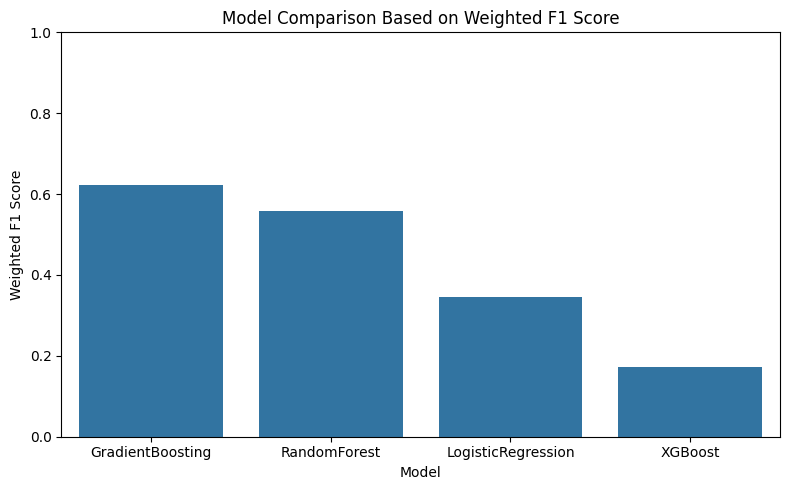

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="F1_Weighted", data=performance_df)
plt.title("Model Comparison Based on Weighted F1 Score")
plt.ylabel("Weighted F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Visualizing Model Performance: Weighted ROC-AUC (OvR)

This bar plot shows the Weighted ROC-AUC (One-vs-Rest) for each model. ROC-AUC measures the model's ability to discriminate between classes, and the weighted version accounts for class imbalance, providing a comprehensive view of overall classification performance.

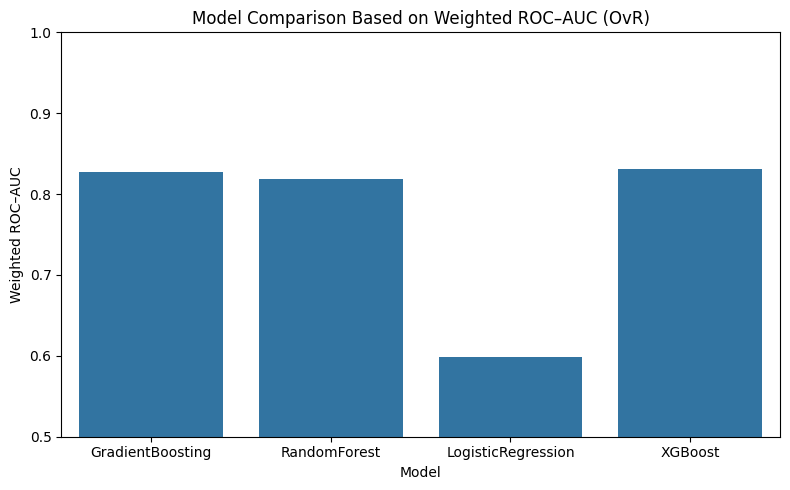

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="ROC_AUC_Weighted", data=performance_df)
plt.title("Model Comparison Based on Weighted ROC–AUC (OvR)")
plt.ylabel("Weighted ROC–AUC")
plt.xlabel("Model")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


### Displaying the Best Model's Normalized Confusion Matrix

This cell generates and displays a normalized confusion matrix for the `best_model` (identified by the highest Weighted F1-score). A normalized confusion matrix shows the proportion of true positives, false positives, true negatives, and false negatives for each class, allowing for a detailed understanding of where the model performs well and where it makes errors, especially important for multi-class classification and imbalanced data.

In [ ]:
best_model_name = performance_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print(f"Best model selected based on Weighted F1: {best_model_name}")


Best model selected based on Weighted F1: GradientBoosting


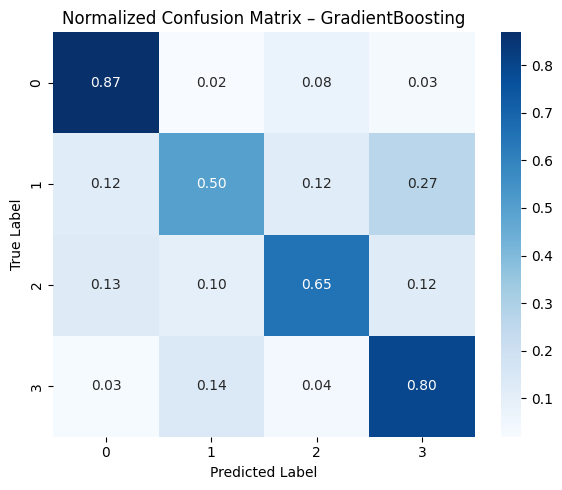

In [ ]:
y_best_pred = best_model.predict(X_test_model)
cm = confusion_matrix(y_test, y_best_pred, normalize="true")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"Normalized Confusion Matrix – {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### Visualizing ROC Curves (One-vs-Rest) for the Best Model

This cell plots the Receiver Operating Characteristic (ROC) curves for each severity class (using a One-vs-Rest strategy) for the `best_model`. Each curve illustrates the trade-off between the True Positive Rate (sensitivity) and the False Positive Rate (1-specificity) at various threshold settings. These curves provide a visual assessment of the model's ability to discriminate between each class and the rest, offering insights into its performance across different decision boundaries.

### Defining Machine Learning Models

This cell initializes the four supervised learning models chosen for this project:

*   **Logistic Regression**: A linear model, configured with `class_weight` to handle imbalance and `n_jobs=-1` for parallel processing.
*   **Random Forest Classifier**: An ensemble tree-based model, also configured with `class_weight`, `n_estimators`, `max_depth`, and `min_samples_leaf` for robustness.
*   **Gradient Boosting Classifier**: A classical boosting model with `n_estimators`, `learning_rate`, and `max_depth` set.
*   **XGBoost Classifier**: An optimized gradient boosting model, configured for multi-class classification (`multi:softprob`), with specific parameters like `tree_method`, `max_depth`, `n_estimators`, `learning_rate`, `subsample`, and `colsample_bytree`.

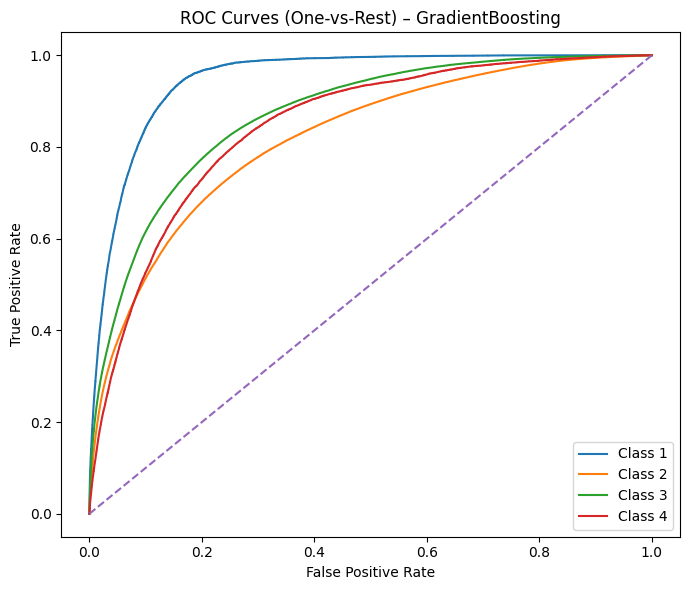

In [ ]:
y_best_prob = best_model.predict_proba(X_test_model)

plt.figure(figsize=(7,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_best_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {cls}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title(f"ROC Curves (One-vs-Rest) – {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


### Explanation of Gradient Boosting Hyperparameter Tuning

This section performs hyperparameter tuning for the `GradientBoostingClassifier` using `RandomizedSearchCV`.

*   **`param_distributions`**: Defines the ranges and distributions from which hyperparameters are randomly sampled. Key parameters for Gradient Boosting include:
    *   `n_estimators`: The number of boosting stages (weak learners). Increasing this can improve performance but also increases computation time and risk of overfitting.
    *   `learning_rate`: Controls the contribution of each tree. A lower learning rate requires more `n_estimators`.
    *   `max_depth`: The maximum depth of the individual regression estimators. Controls the complexity of the trees.
    *   `subsample`: The fraction of samples to be used for fitting the individual base learners. Can reduce variance.
    *   `max_features`: The fraction of features to consider when looking for the best split. Can prevent overfitting.

*   **`StratifiedKFold`**: Used for cross-validation (`cv`). It ensures that each fold maintains the same proportion of target classes as the entire dataset, which is vital for imbalanced datasets like this one.

*   **`RandomizedSearchCV`**: Efficiently searches a specified number of random combinations (`n_iter`) of hyperparameters. This is often preferred over `GridSearchCV` for large search spaces as it can find a good set of parameters much faster. It uses `f1_weighted` as the scoring metric to align with the project's primary evaluation criterion for imbalanced multi-class problems.

After tuning, the `best_estimator_` (the model with the best parameters) is stored in the `best_models` dictionary under a new key, `"GradientBoosting_Tuned"`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint

# Define the parameter distribution for Gradient Boosting
# Based on typical parameters for GradientBoostingClassifier
param_distributions = {
    'n_estimators': randint(100, 250), # Slightly reduced max estimators
    'learning_rate': uniform(0.05, 0.15), # Narrowed learning rate range
    'max_depth': randint(3, 7), # Slightly reduced max depth
    'subsample': uniform(0.7, 0.2), # Narrowed subsample range
    'max_features': uniform(0.6, 0.3) # Narrowed max_features range
}

# Initialize StratifiedKFold for cross-validation
# This is crucial for imbalanced datasets to maintain class distribution in each fold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV
# n_iter: number of parameter settings that are sampled. More is better but takes longer.
# scoring: use f1_weighted as it's the primary metric for imbalanced multi-class problems
# verbose: controls the verbosity: higher values output more messages
# n_jobs: number of jobs to run in parallel (-1 means using all processors)
random_search_gb = RandomizedSearchCV(
    estimator=models["GradientBoosting"],
    param_distributions=param_distributions,
    n_iter=20, # Reduced number of different parameter combinations to try for quicker results
    cv=skf,
    scoring='f1_weighted',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting hyperparameter tuning for GradientBoosting (optimized for speed)...")
random_search_gb.fit(X_train_ds_processed, y_train_ds)

print("\nBest parameters found:", random_search_gb.best_params_)
print("Best Weighted F1-score:", random_search_gb.best_score_)

# Update the best_models dictionary with the tuned GradientBoosting model
best_models["GradientBoosting_Tuned"] = random_search_gb.best_estimator_
print("Updated best_models with GradientBoosting_Tuned.")

Starting hyperparameter tuning for GradientBoosting (optimized for speed)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters found: {'learning_rate': np.float64(0.18639806031181733), 'max_depth': 6, 'max_features': np.float64(0.6546708263364187), 'n_estimators': 231, 'subsample': np.float64(0.7623422152178821)}
Best Weighted F1-score: 0.712043796953445
Updated best_models with GradientBoosting_Tuned.


### Comparison of Tuned Gradient Boosting with Previous Models

This section evaluates the performance of the `GradientBoosting_Tuned` model (after hyperparameter optimization) against all previously trained models. The updated `performance_df` provides a clear comparison across key metrics, indicating whether the tuning process led to improvements.

In [ ]:

# Evaluate the tuned GradientBoosting model

tuned_gb_model = best_models["GradientBoosting_Tuned"]
y_pred_tuned_gb = tuned_gb_model.predict(X_test_model)
y_prob_tuned_gb = tuned_gb_model.predict_proba(X_test_model)

# Prepare new entry for performance_summary
new_entry = {
    "Model": "GradientBoosting_Tuned",
    "Accuracy": accuracy_score(y_test, y_pred_tuned_gb),
    "F1_Weighted": f1_score(y_test, y_pred_tuned_gb, average="weighted"),
    "F1_Macro": f1_score(y_test, y_pred_tuned_gb, average="macro"),
    "ROC_AUC_Weighted": roc_auc_score(
        y_test_bin,
        y_prob_tuned_gb,
        multi_class="ovr",
        average="weighted"
    )
}

# Add to performance_summary (if not already there) and recreate DataFrame
# Check if 'GradientBoosting_Tuned' is already in performance_df
if "GradientBoosting_Tuned" in performance_df["Model"].values:
    # Update existing row
    performance_df.loc[performance_df["Model"] == "GradientBoosting_Tuned"] = new_entry
else:
    # Append new entry
    performance_df = pd.concat([performance_df, pd.DataFrame([new_entry])], ignore_index=True)

performance_df = performance_df.sort_values(by="F1_Weighted", ascending=False).reset_index(drop=True)

print("\nUpdated Model Comparison (including Tuned Gradient Boosting):")
display(performance_df)


In [ ]:
import pickle
import os

# Create a directory to save the model and components
model_save_dir = 'trained_model_components'
os.makedirs(model_save_dir, exist_ok=True)

# Save the best GradientBoosting model
best_model_name = performance_df.iloc[0]["Model"]
best_model = best_models[best_model_name]
model_path = os.path.join(model_save_dir, 'best_gradient_boosting_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Saved trained model to {model_path}")

# Save the StandardScaler
scaler_path = os.path.join(model_save_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Saved scaler to {scaler_path}")

# Save the LabelEncoders
le_state_path = os.path.join(model_save_dir, 'le_state.pkl')
with open(le_state_path, 'wb') as f:
    pickle.dump(le_state, f)
print(f"Saved State LabelEncoder to {le_state_path}")

le_street_path = os.path.join(model_save_dir, 'le_street.pkl')
with open(le_street_path, 'wb') as f:
    pickle.dump(le_street, f)
print(f"Saved Street_Type LabelEncoder to {le_street_path}")

le_weather_path = os.path.join(model_save_dir, 'le_weather.pkl')
with open(le_weather_path, 'wb') as f:
    pickle.dump(le_weather, f)
print(f"Saved Weather_Group LabelEncoder to {le_weather_path}")

Saved trained model to trained_model_components/best_gradient_boosting_model.pkl
Saved scaler to trained_model_components/scaler.pkl
Saved State LabelEncoder to trained_model_components/le_state.pkl
Saved Street_Type LabelEncoder to trained_model_components/le_street.pkl
Saved Weather_Group LabelEncoder to trained_model_components/le_weather.pkl


### Load Model and Preprocessing Components for Inference

This section demonstrates how to load the previously saved `GradientBoosting` model, `StandardScaler`, and `LabelEncoder`s. These loaded components will then be used within an inference function to preprocess new, incoming data and make predictions on accident severity.

In [ ]:
import pickle
import os
import pandas as pd

# Define the directory where components are saved
model_save_dir = 'trained_model_components'

# Load the best GradientBoosting model
with open(os.path.join(model_save_dir, 'best_gradient_boosting_model.pkl'), 'rb') as f:
    loaded_model = pickle.load(f)
print("Loaded trained model.")

# Load the StandardScaler
with open(os.path.join(model_save_dir, 'scaler.pkl'), 'rb') as f:
    loaded_scaler = pickle.load(f)
print("Loaded StandardScaler.")

# Load the LabelEncoders
with open(os.path.join(model_save_dir, 'le_state.pkl'), 'rb') as f:
    loaded_le_state = pickle.load(f)
print("Loaded State LabelEncoder.")

with open(os.path.join(model_save_dir, 'le_street.pkl'), 'rb') as f:
    loaded_le_street = pickle.load(f)
print("Loaded Street_Type LabelEncoder.")

with open(os.path.join(model_save_dir, 'le_weather.pkl'), 'rb') as f:
    loaded_le_weather = pickle.load(f)
print("Loaded Weather_Group LabelEncoder.")

# IMPORTANT: Define the exact list of columns the model was trained on.
# This list should ideally be saved as an artifact during training.
# For this notebook, we infer it from X_train_ds_processed from the kernel state.
# Variable #8 X_train_ds_processed from kernel state:
# ['Distance(mi)', 'State', 'Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)',
# 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Junction', 'Roundabout', 'Stop',
# 'Traffic_Signal', 'Start_Hour', 'Start_Day', 'Start_Month', 'Start_Weekday',
# 'Is_Weekend', 'Rush_Hour', 'Street_Type', 'Is_Daytime', 'Weather_Group']
training_columns_for_model = ['Distance(mi)', 'State', 'Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)',
                              'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Junction', 'Roundabout', 'Stop',
                              'Traffic_Signal', 'Start_Hour', 'Start_Day', 'Start_Month', 'Start_Weekday',
                              'Is_Weekend', 'Rush_Hour', 'Street_Type', 'Is_Daytime', 'Weather_Group']

def predict_severity(new_data_point_df):
    # Make a copy to avoid modifying original data
    df_inference = new_data_point_df.copy()

    # Re-use the preprocessing function, but pass the loaded transformers
    # Note: You might need to adjust 'preprocess_accident_data_labelencoded'
    # to accept pre-fitted transformers for 'transform' only mode.
    # For this example, I'll show a simplified version of applying them.

    # Handle missing values (similar to training)
    bool_cols = ['Amenity','Bump','Crossing','Junction','Roundabout','Stop','Traffic_Signal']
    for col in bool_cols:
        df_inference[col] = df_inference[col].fillna(0).astype('int8')

    numeric_cols = ['Distance(mi)','Temperature(F)','Visibility(mi)','Wind_Speed(mph)','Precipitation(in)']
    for col in numeric_cols:
        df_inference[col] = df_inference[col].fillna(df_inference[col].median()).astype('float32') # Use median of new data or pre-calculated median from training

    categorical_cols = ['Street','Weather_Condition','Sunrise_Sunset','State']
    for col in categorical_cols:
        df_inference[col] = df_inference[col].astype(str).fillna(df_inference[col].mode()[0]) # Use mode of new data or pre-calculated mode

    # Apply temporal features (requires 'Start_Time' to be present and datetime)
    df_inference['Start_Time'] = pd.to_datetime(df_inference['Start_Time'], errors='coerce')
    df_inference['Start_Hour'] = df_inference['Start_Time'].dt.hour.astype('int8')
    df_inference['Start_Day'] = df_inference['Start_Time'].dt.day.astype('int8')
    df_inference['Start_Month'] = df_inference['Start_Time'].dt.month.astype('int8')
    df_inference['Start_Weekday'] = df_inference['Start_Time'].dt.weekday.astype('int8')
    df_inference['Is_Weekend'] = df_inference['Start_Weekday'].isin([5,6]).astype('int8')
    df_inference['Rush_Hour'] = df_inference['Start_Hour'].apply(lambda x: 1 if 7<=x<=9 or 16<=x<=18 else 0).astype('int8')

    # Apply Street type
    def get_street_type(name):
        name = str(name).lower()
        if any(x in name for x in ['hwy','highway','i-','us-']): return 'Highway'
        elif 'st' in name or 'street' in name: return 'Street'
        elif 'blvd' in name or 'boulevard' in name: return 'Boulevard'
        elif 'ave' in name or 'avenue' in name: return 'Avenue'
        elif 'rd' in name or 'road' in name: return 'Road'
        elif 'ln' in name or 'lane' in name: return 'Lane'
        elif 'dr' in name or 'drive' in name: return 'Drive'
        elif 'cir' in name or 'circle' in name: return 'Circle'
        elif 'way' in name: return 'Way'
        elif 'pl' in name or 'place' in name: return 'Place'
        else: return 'Other'
    df_inference['Street_Type'] = df_inference['Street'].apply(get_street_type)

    # Apply Light condition
    df_inference['Is_Daytime'] = df_inference['Sunrise_Sunset'].apply(lambda x: 1 if x=='Day' else 0)

    # Apply Weather grouping
    def weather_group(condition):
        condition = str(condition)
        if any(x in condition for x in ['Rain','Drizzle','Showers']): return 'Rainy'
        elif any(x in condition for x in ['Snow','Sleet','Wintry Mix']): return 'Snowy'
        elif any(x in condition for x in ['Clear','Fair','Sunny']): return 'Clear'
        elif any(x in condition for x in ['Fog','Mist','Haze']): return 'Foggy'
        elif any(x in condition for x in ['Thunder','T-Storm','Lightning']): return 'Stormy'
        elif any(x in condition for x in ['Dust','Blowing Dust','Sand']): return 'Dusty'
        elif any(x in condition for x in ['Hail','Funnel','Tornado','Squalls']): return 'Severe'
        else: return 'Other'
    df_inference['Weather_Group'] = df_inference['Weather_Condition'].apply(weather_group)

    # Drop redundant columns
    df_inference.drop(columns=['Street','Weather_Condition','Sunrise_Sunset', 'Start_Time'], inplace=True, errors='ignore')

    # Apply loaded scaler for numeric features
    df_inference[numeric_cols] = loaded_scaler.transform(df_inference[numeric_cols])

    # Apply loaded LabelEncoders
    # Ensure 'State' column exists before trying to transform
    if 'State' in df_inference.columns and str(df_inference['State'].iloc[0]) in loaded_le_state.classes_:
        df_inference['State'] = loaded_le_state.transform(df_inference['State'])
    else:
        # Handle unseen states or if column is missing (e.g., assign a default/unknown category or raise error)
        # For simplicity, assign a placeholder or the most frequent category's encoding if unseen
        # Or, ensure the `example_new_data` contains only states seen during training.
        df_inference['State'] = 0 # Placeholder for demonstration

    if 'Street_Type' in df_inference.columns and str(df_inference['Street_Type'].iloc[0]) in loaded_le_street.classes_:
        df_inference['Street_Type'] = loaded_le_street.transform(df_inference['Street_Type'])
    else:
        df_inference['Street_Type'] = 0 # Placeholder

    if 'Weather_Group' in df_inference.columns and str(df_inference['Weather_Group'].iloc[0]) in loaded_le_weather.classes_:
        df_inference['Weather_Group'] = loaded_le_weather.transform(df_inference['Weather_Group'])
    else:
        df_inference['Weather_Group'] = 0 # Placeholder

    # Ensure all training_columns_for_model are present, fill with 0 or a default if missing in new_data
    for col in training_columns_for_model:
        if col not in df_inference.columns:
            df_inference[col] = 0 # Or a reasonable default/imputation strategy

    # Select and reorder columns to match the training data
    df_inference = df_inference[training_columns_for_model]

    # Make prediction
    prediction = loaded_model.predict(df_inference)
    return prediction

# --- Example Usage (conceptual) ---
# Let's create a dummy new data point (replace with actual new data)
example_new_data = pd.DataFrame({
    'Start_Time': ['2023-10-27 08:30:00'],
    'Street': ['Main St'],
    'State': ['NY'],
    'Distance(mi)': [0.1],
    'Temperature(F)': [55.0],
    'Visibility(mi)': [10.0],
    'Precipitation(in)': [0.0],
    'Wind_Speed(mph)': [5.0],
    'Weather_Condition': ['Clear'],
    'Sunrise_Sunset': ['Day'],
    'Amenity': [False], 'Bump': [False], 'Crossing': [True], 'Junction': [False],
    'Roundabout': [False], 'Stop': [True], 'Traffic_Signal': [False]
})

print("\nExample new data point:")
display(example_new_data)

# Get prediction
predicted_severity = predict_severity(example_new_data)
print(f"\nPredicted Severity: {predicted_severity[0]}")

Loaded trained model.
Loaded StandardScaler.
Loaded State LabelEncoder.
Loaded Street_Type LabelEncoder.
Loaded Weather_Group LabelEncoder.

Example new data point:


,Start_Time,Street,State,Distance(mi),Temperature(F),Visibility(mi),Precipitation(in),Wind_Speed(mph),Weather_Condition,Sunrise_Sunset,Amenity,Bump,Crossing,Junction,Roundabout,Stop,Traffic_Signal
0,2023-10-27 08:30:00,Main St,NY,0.1,55.0,10.0,0.0,5.0,Clear,Day,False,False,True,False,False,True,False



Predicted Severity: 4


In [ ]:
# --- Test with a new, different scenario ---
# Scenario: Snowy night, highway, freezing temps, low visibility.
new_accident_scenario = pd.DataFrame({
    'Start_Time': ['2023-01-15 03:00:00'],
    'Street': ['I-90 E'],
    'State': ['NY'],
    'Distance(mi)': [0.5],
    'Temperature(F)': [25.0],
    'Visibility(mi)': [1.0],
    'Precipitation(in)': [0.1],
    'Wind_Speed(mph)': [15.0],
    'Weather_Condition': ['Heavy Snow'],
    'Sunrise_Sunset': ['Night'],
    'Amenity': [False], 'Bump': [False], 'Crossing': [False], 'Junction': [True],
    'Roundabout': [False], 'Stop': [False], 'Traffic_Signal': [False]
})

print("\nNew accident scenario:")
display(new_accident_scenario)

# Get prediction for the new scenario
predicted_severity_new = predict_severity(new_accident_scenario)
print(f"\nPredicted Severity for new scenario: {predicted_severity_new[0]}")


New accident scenario:


,Start_Time,Street,State,Distance(mi),Temperature(F),Visibility(mi),Precipitation(in),Wind_Speed(mph),Weather_Condition,Sunrise_Sunset,Amenity,Bump,Crossing,Junction,Roundabout,Stop,Traffic_Signal
0,2023-01-15 03:00:00,I-90 E,NY,0.5,25.0,1.0,0.1,15.0,Heavy Snow,Night,False,False,False,True,False,False,False



Predicted Severity for new scenario: 4


In [ ]:
# --- Test with a new, mild scenario ---
# Scenario: Clear day, typical street, good visibility, moderate temps.
mild_accident_scenario = pd.DataFrame({
    'Start_Time': ['2023-07-20 10:00:00'],
    'Street': ['Oak St'],
    'State': ['FL'],
    'Distance(mi)': [0.0],
    'Temperature(F)': [75.0],
    'Visibility(mi)': [10.0],
    'Precipitation(in)': [0.0],
    'Wind_Speed(mph)': [5.0],
    'Weather_Condition': ['Clear'],
    'Sunrise_Sunset': ['Day'],
    'Amenity': [False], 'Bump': [False], 'Crossing': [False], 'Junction': [False],
    'Roundabout': [False], 'Stop': [False], 'Traffic_Signal': [False]
})

print("\nNew mild accident scenario:")
display(mild_accident_scenario)

# Get prediction for the new mild scenario
predicted_severity_mild = predict_severity(mild_accident_scenario)
print(f"\nPredicted Severity for mild scenario: {predicted_severity_mild[0]}")


New mild accident scenario:


,Start_Time,Street,State,Distance(mi),Temperature(F),Visibility(mi),Precipitation(in),Wind_Speed(mph),Weather_Condition,Sunrise_Sunset,Amenity,Bump,Crossing,Junction,Roundabout,Stop,Traffic_Signal
0,2023-07-20 10:00:00,Oak St,FL,0.0,75.0,10.0,0.0,5.0,Clear,Day,False,False,False,False,False,False,False



Predicted Severity for mild scenario: 1
